In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
import plotly.express as px

warnings.filterwarnings('ignore')


In [2]:
df = sns.load_dataset('tips')
df
sns.set_theme()
sns.set_style("whitegrid")
sns.set_context("talk")
sns.set_palette("Set2")

In [3]:
data = pd.read_csv("AB_NYC_2019.csv")

In [51]:
data

,id,name,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,unknown,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,unknown,0.00,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,unknown,0.00,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,unknown,0.00,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,unknown,0.00,6,2


In [52]:
data.info()

<class 'pandas.DataFrame'>
Index: 47840 entries, 0 to 48894
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              47840 non-null  int64  
 1   name                            47840 non-null  str    
 2   host_id                         47840 non-null  int64  
 3   neighbourhood_group             47840 non-null  str    
 4   neighbourhood                   47840 non-null  str    
 5   latitude                        47840 non-null  float64
 6   longitude                       47840 non-null  float64
 7   room_type                       47840 non-null  str    
 8   price                           47840 non-null  int64  
 9   minimum_nights                  47840 non-null  int64  
 10  number_of_reviews               47840 non-null  int64  
 11  last_review                     47840 non-null  str    
 12  reviews_per_month               47840 non-null  

In [6]:
data['last_review'] = data['last_review'].fillna('unknown', inplace= True)
data['reviews_per_month'] = data['reviews_per_month'].fillna(0, inplace= True)  

In [7]:
data['name'] = data['name'].fillna('unknown', inplace= True)

In [8]:
data.drop('host_name', axis= 1, inplace= True)

In [9]:
data.drop(data[data['price'] == 0].index, inplace= True)

In [50]:
data.drop(data[data['price'] > 500].index, inplace= True)

In [53]:
#mean price of listings in each neighbourhood group
data.groupby('neighbourhood_group')['price'].mean().sort_values(ascending= True)


neighbourhood_group
Bronx             81.818098
Staten Island     91.144414
Queens            92.850807
Brooklyn         112.679251
Manhattan        163.255805
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='neighbourhood_group'>

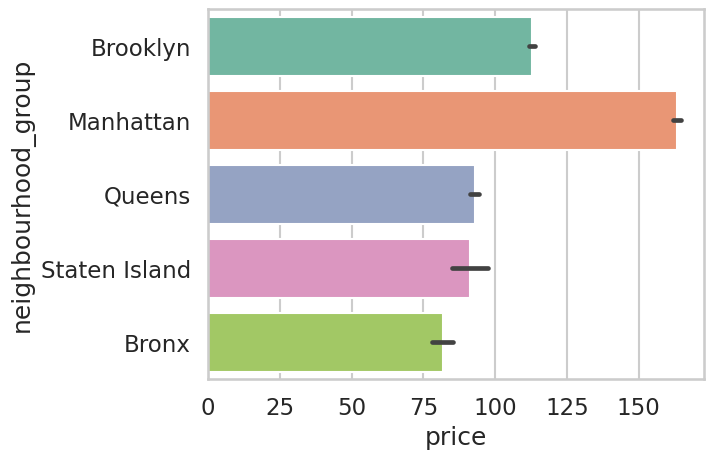

In [54]:
sns.barplot(y= 'neighbourhood_group', x= 'price', data= data, palette= 'Set2')

In [55]:
#median price of listings in each neighbourhood group
data.groupby('neighbourhood_group')['price'].median().sort_values(ascending= True)

neighbourhood_group
Bronx             65.0
Queens            75.0
Staten Island     75.0
Brooklyn          90.0
Manhattan        145.0
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='neighbourhood_group'>

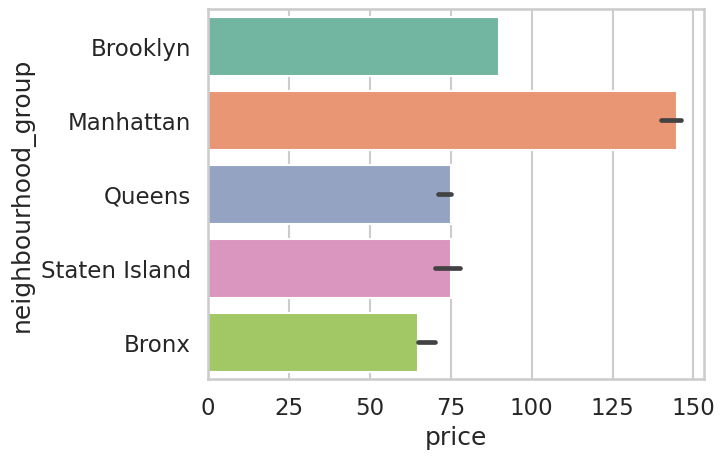

In [56]:
sns.barplot(y= 'neighbourhood_group', x= 'price', data= data, estimator= np.median, palette= 'Set2')

In [57]:
#SD price of listings in each neighbourhood group
data.groupby('neighbourhood_group')['price'].std().sort_values(ascending= True)

neighbourhood_group
Bronx            60.748118
Staten Island    63.075143
Queens           64.053356
Brooklyn         75.613676
Manhattan        95.114873
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='neighbourhood_group'>

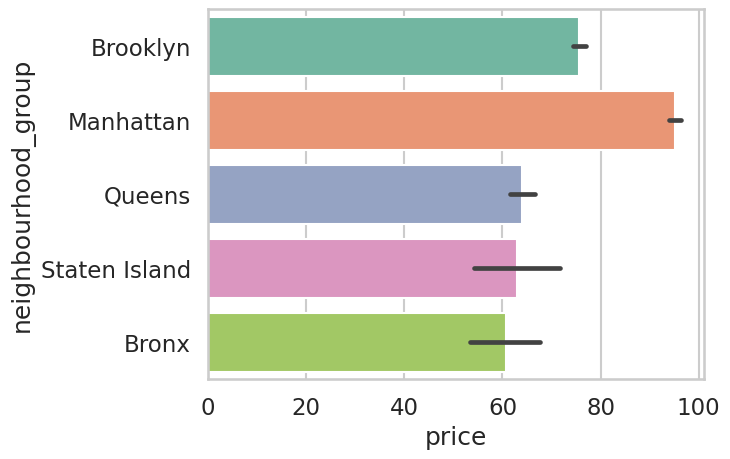

In [58]:
sns.barplot(y= 'neighbourhood_group', x= 'price', data= data , estimator= np.std, palette= 'Set2')

In [59]:
#Average availability of room type
data.groupby('room_type')['availability_365'].mean().sort_values(ascending= True)

room_type
Entire home/apt    109.303990
Private room       110.653409
Shared room        162.345217
Name: availability_365, dtype: float64

<Axes: xlabel='availability_365', ylabel='room_type'>

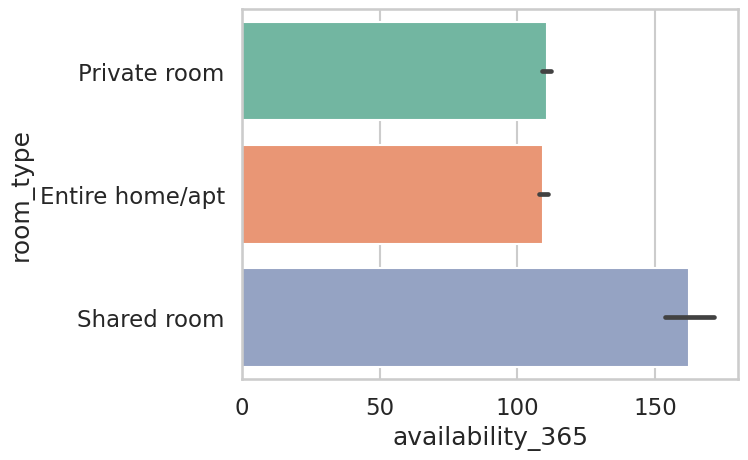

In [60]:
sns.barplot(y= 'room_type', x= 'availability_365', data= data, estimator= np.mean, palette= 'Set2')

In [61]:
#correlation between price and availability and number of reviews
data[['price', 'availability_365', 'number_of_reviews']].corr()


,price,availability_365,number_of_reviews
price,1.000000,0.094630,-0.048237
availability_365,0.094630,1.000000,0.177573
number_of_reviews,-0.048237,0.177573,1.000000


<Axes: >

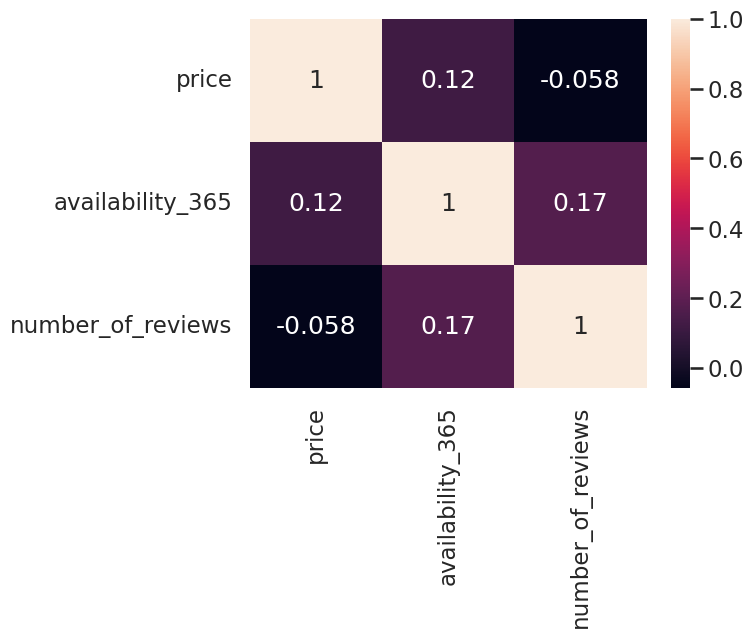

In [45]:
sns.heatmap(data[['price', 'availability_365', 'number_of_reviews']].corr(), annot= True)

<Axes: xlabel='price', ylabel='Count'>

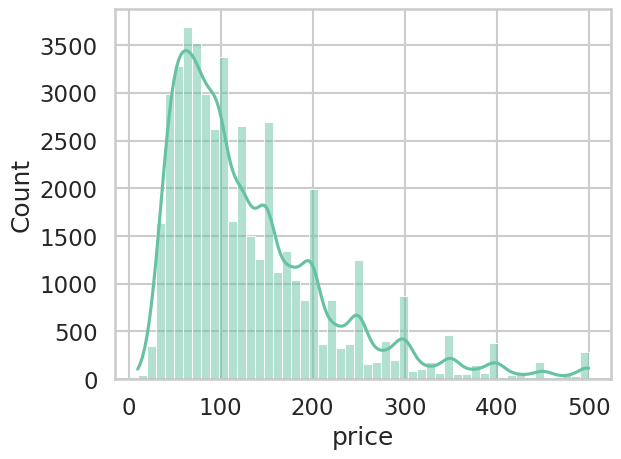

In [70]:
sns.histplot(x=data['price'], bins= 50, kde= True, palette= 'Set2')

In [71]:
data['price'].skew()

np.float64(1.5583339426136822)

<Axes: xlabel='price'>

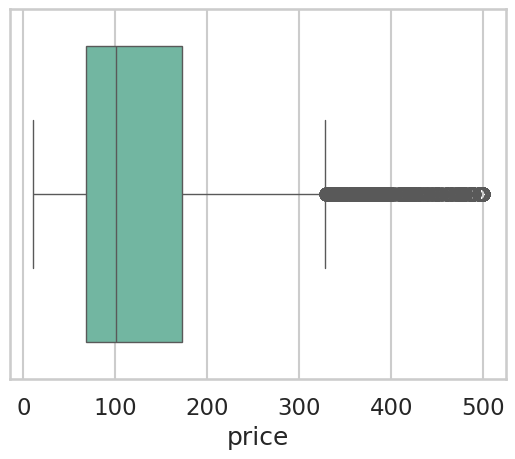

In [72]:
sns.boxplot(x= data['price'])

<Axes: xlabel='price', ylabel='neighbourhood_group'>

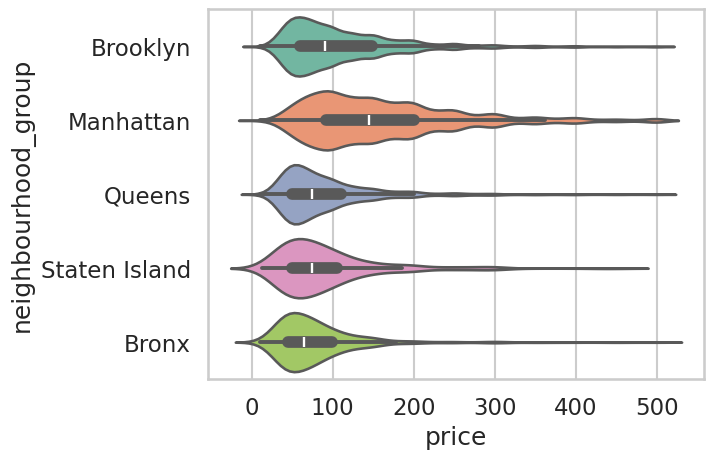

In [74]:
sns.violinplot(x= 'price', y= 'neighbourhood_group', data= data, palette= 'Set2')

<Axes: xlabel='longitude', ylabel='latitude'>

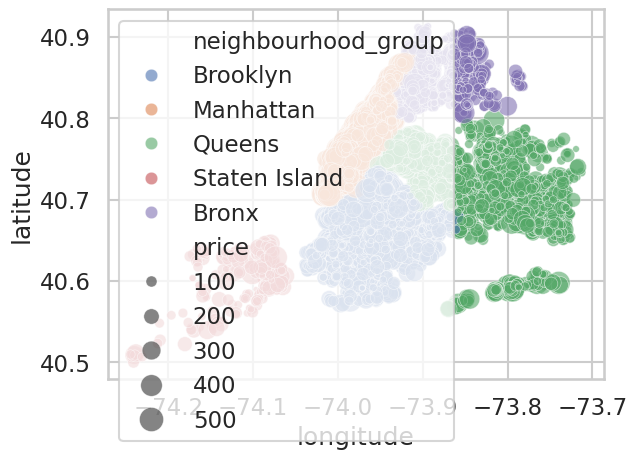

In [78]:
sns.scatterplot(x='longitude', y= 'latitude', data= data, hue= 'neighbourhood_group', sizes=(10, 300),alpha=0.6,palette='deep', size= 'price')

In [83]:
data

,id,name,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,unknown,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,unknown,0.00,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,unknown,0.00,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,unknown,0.00,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,unknown,0.00,6,2


In [92]:
new_data = data.groupby('host_id')['price'].agg(mean_price ='mean', listing_count = 'count')
new_data

,mean_price,listing_count
host_id,,
2438,95.000000,1
2571,182.000000,1
2787,100.666667,6
2845,162.000000,2
2868,60.000000,1
...,...,...
274273284,140.000000,1
274298453,54.000000,1
274307600,190.000000,1


In [97]:
if ((new_data[new_data['listing_count'] == 1]['mean_price'].mean()) < (new_data[new_data['listing_count'] > 1]['mean_price'].mean())):
    print("Hosts with more than 1 listing charges more on average than hosts with only 1 listing")
elif ((new_data[new_data['listing_count'] == 1]['mean_price'].mean()) > (new_data[new_data['listing_count'] > 1]['mean_price'].mean())):
    print("Hosts with only 1 listing charges more on average than hosts with more than 1 listing")

Hosts with only 1 listing charges more on average than hosts with more than 1 listing


<Axes: xlabel='mean_price', ylabel='listing_count'>

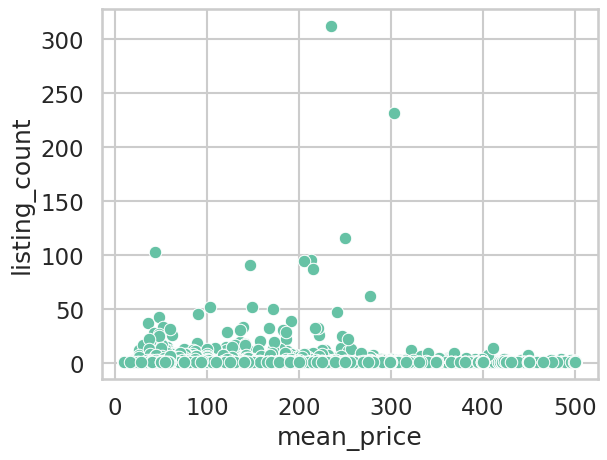

In [99]:
sns.scatterplot(y = 'listing_count', x= 'mean_price', data= new_data, palette= 'Set2')